In [23]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import sys, pickle
from importlib import reload
from tqdm import tqdm, trange

import numpy as np, pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm
#from matplotlib import rc
# rc('text', usetex=True)
# # Set the font family to 'serif' and specify a LaTeX font like 'Computer Modern'
# rc('font', family='serif', serif=['Computer Modern'])

import agama 
agama.setUnits(mass=1, length=1, velocity=1) #Msol, kpc, km/s. Time is in kpc/(kms/s)
# agama.setNumThreads(48)  

# sys.path.insert(1, '/mnt/d/Research/')
# import compute_characteristics_ut as cc

import jet_sim_funcs as jsf

import emcee
import corner

from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import Galactocentric, ICRS, CartesianDifferential, CartesianRepresentation
from astropy import table

from jet_likelihood_5D import log_likelihood, make_spline, log_prior, log_probability
from jet_sim_funcs import create_stream_particle_spray, generate_stream_coords

In [24]:
# Define file paths
BASE_POT_PATH = 'Nbody_streams/nbody_streams/data/potentials'
potMW_path = os.path.join(BASE_POT_PATH, 'MWPotential22.ini')
## potential models to load
potMW = agama.Potential(file=potMW_path)
potTotal= agama.Potential(potMW)

In [25]:
#coordinate transform (useful for plotting)
def icrs_to_jet(ra_deg, dec_deg):
    """
    define a *differentiable* coordinate transfrom from ra and dec --> Jet phi1, phi2
    Using the rotation matrix from Shipp+2019
    ra_deg: icrs deg [degrees]
    dec_deg: icrs deg [degrees]
    """
    ra_rad = np.radians(ra_deg)
    dec_rad = np.radians(dec_deg)
    
    R = np.array(
        [
            [-0.69796993, 0.6112632, -0.37308885],
            [-0.62616799, -0.26812463, 0.7321358],
            [0.34749337, 0.74462505, 0.56989637],
        ]
    )

    icrs_vec = np.vstack(
        [
            np.cos(ra_rad) * np.cos(dec_rad),
            np.sin(ra_rad) * np.cos(dec_rad),
            np.sin(dec_rad),
        ]
    ).T

    stream_frame_vec = np.einsum("ij,kj->ki", R, icrs_vec)

    phi1 = np.arctan2(stream_frame_vec[:, 1], stream_frame_vec[:, 0]) * 180 / np.pi
    phi2 = np.arcsin(stream_frame_vec[:, 2]) * 180 / np.pi

    return phi1, phi2

In [26]:
#Reading in all our data
member_path = 'jet_members.csv'

jet_table = pd.read_csv(member_path)

def select_median_array(data_file):
    
    '''
    Function takes in data table and spits out median star and data_dict
    '''
    
    df = data_file

    select_phi1 = (df['phi1'] > -1.0) & (df['phi1'] < 5.0)
    
    select_distance = (df['bhb_dist'].notna())
    dist_phi1 = df.loc[select_distance, 'phi1']
    dist = df.loc[select_distance, 'bhb_dist']


    coefficients = np.polyfit(dist_phi1, dist, deg=1)

    distance_fit = np.poly1d(coefficients)

    phi1med = np.median(df.loc[select_phi1,'phi1'])
    phi2med = np.median(df.loc[select_phi1,'phi2'])
    distmed = np.median(df.loc[select_phi1 & select_distance, 'bhb_dist'])
    ramed = np.median(df.loc[select_phi1,'ra'])
    decmed = np.median(df.loc[select_phi1,'dec'])
    pmramed = np.median(df.loc[select_phi1, 'pmra'])
    pmdecmed = np.median(df.loc[select_phi1, 'pmdec'])
    rvmed = np.median(df.loc[select_phi1, 'vel_calib'])

    prog_pars = [float(phi1med), float(phi2med), float(distmed), float(pmramed), float(pmdecmed), float(rvmed)]
    prog_pars_icrs = [float(ramed), float(decmed), float(distmed), float(pmramed), float(pmdecmed), float(rvmed)]

    return df, distance_fit, prog_pars, prog_pars_icrs

df, distance_fit, prog_pars, prog_pars_icrs = select_median_array(jet_table)

In [27]:
ra, dec, dist, pmra, pmdec, rv = [140.38299113, -19.72515122,  30.13981512,  -0.7037447,   -1.55066266,
 274.43070988]

jet_c = coord.SkyCoord(
    ra=ra*u.degree, dec=dec*u.degree, distance=dist*u.kpc, 
    pm_ra_cosdec=pmra*u.mas/u.yr,
    pm_dec=pmdec*u.mas/u.yr,
    radial_velocity=rv*u.km/u.s
)

rep = jet_c.transform_to(coord.Galactocentric) # units here are kpc, km/s

prog_wtoday = np.array(
    [rep.x.value, rep.y.value, rep.z.value,
     rep.v_x.value, rep.v_y.value, rep.v_z.value]
) # units here are kpc, km/s


# # stream progenitor profile parameters
prog_mass, prog_scaleradius =  20_000, 10/1_000 # Msun, kpc
Age_stream_inGyr = 6.0 # Gyr --<

# # num_particles for the spray model: 
num_particles = 2_000 # # preferably a multiple of 2, leading+trailing arm

# Test out a particle-spray simulation
stream_unperturb = jsf.create_stream_particle_spray(
    pot_host=potTotal, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_wtoday, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1,
    # add_perturber={'mass':0},
)
stream_model = stream_unperturb['part_xv']

In [28]:
galcen_stream = coord.Galactocentric(
        x=stream_model[:,0] * u.kpc,
        y=stream_model[:,1] * u.kpc,
        z=stream_model[:,2] * u.kpc,
        v_x=stream_model[:,3] * u.km/u.s,
        v_y=stream_model[:,4] * u.km/u.s,
        v_z=stream_model[:,5] * u.km/u.s,
        representation_type='cartesian',
        differential_type='cartesian'
    )

icrs_stream = galcen_stream.transform_to(coord.ICRS())

ra_model = icrs_stream.ra.value
dec_model = icrs_stream.dec.value
dist_model = icrs_stream.distance.value
pmra_model = icrs_stream.pm_ra_cosdec.value
pmdec_model = icrs_stream.pm_dec.value
rv_model = icrs_stream.radial_velocity.value

phi1_model, phi2_model = icrs_to_jet(ra_model, dec_model)

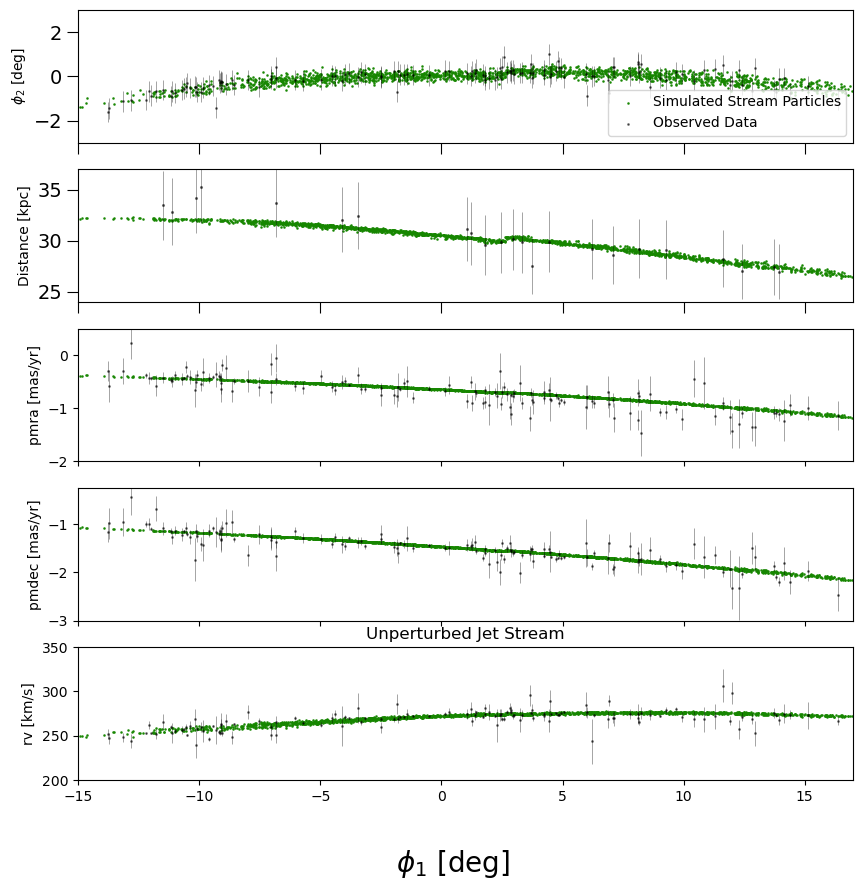

In [29]:
#plot with best-fit progenitor IC's from MCMC!

fig, ax = plt.subplots(5,1, sharex = True)
fig.set_size_inches(10,10)
fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
ax[-1].set_xlim(-15,17)
ax[-1].set_title(label ='Unperturbed Jet Stream',loc='center' )
#simulation
ax[0].scatter(phi1_model, phi2_model,s=0.75,color='#168600', alpha= 0.9, label = 'Simulated Stream Particles')
ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[0].tick_params(axis='both', which='minor', length=3)
ax[0].set_ylim(-3,3)
ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)

ax[1].scatter(phi1_model, dist_model,s=0.75,color='#168600',alpha= 0.9 )
ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[1].tick_params(axis='both', which='minor', length=3)
ax[1].set_ylabel('Distance [kpc]', fontsize=10)
ax[1].set_ylim(24,37)

ax[2].scatter(phi1_model, pmra_model,s=0.75,color='#168600',alpha= 0.9 )
ax[2].set_ylim(-1,1)
ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)
ax[2].set_ylim(-2,0.5)

ax[3].scatter(phi1_model, pmdec_model,s=0.75,color='#168600',alpha= 0.9 )
ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
ax[3].set_ylim(-3,-0.25)

ax[4].scatter(phi1_model, rv_model,s=0.75,color='#168600',alpha= 0.9)
ax[4].set_ylabel('rv [km/s]', fontsize=10)
ax[4].set_ylim(200,350)

#data
ax[0].scatter(df['phi1'], df['phi2'] , s=1,color='k', alpha = 0.5, label = 'Observed Data')
ax[0].errorbar(df['phi1'], df['phi2'], yerr=np.nanstd(df['phi2']), fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[1].scatter(df['phi1'], df['bhb_dist'],s=1.5,color='k', alpha = 0.5)
ax[1].errorbar(df['phi1'],df['bhb_dist'], yerr=((df['bhb_dist'].values)*0.1), fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)


ax[2].scatter(df['phi1'], df['pmra'],s=1,color='k', alpha = 0.5)
ax[2].errorbar(df['phi1'], df['pmra'], yerr=df['pmra_error'], fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)

ax[3].scatter(df['phi1'], df['pmdec'],s=1,color='k',alpha = 0.5)
ax[3].errorbar(df['phi1'], df['pmdec'], yerr=df['pmdec_error'], fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[4].scatter(df['phi1'], df['vel_calib'],s=1,color='k', alpha = 0.5)
ax[4].errorbar(df['phi1'], df['vel_calib'], yerr=df['vel_calib_std'], fmt='none', ecolor='k',alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[0].legend(loc = 'lower right')

In [30]:
#for loop and create a gif

In [31]:
loop_stream_age = 0.0

for i in np.arange(0.1, 6.0, 0.1):
    loop_stream_age = i
    stream_unperturb = jsf.create_stream_particle_spray(
        pot_host=potTotal, 
        initmass=prog_mass, 
        scaleradius=prog_scaleradius, 
        prog_pot_kind='Plummer', 
        sat_cen_present=prog_wtoday, 
        num_particles=num_particles,
        time_end=0.0, 
        time_total=loop_stream_age, save_rate=1,
        # add_perturber={'mass':0},
    )
    stream_model = stream_unperturb['part_xv']
    galcen_stream = coord.Galactocentric(
        x=stream_model[:,0] * u.kpc,
        y=stream_model[:,1] * u.kpc,
        z=stream_model[:,2] * u.kpc,
        v_x=stream_model[:,3] * u.km/u.s,
        v_y=stream_model[:,4] * u.km/u.s,
        v_z=stream_model[:,5] * u.km/u.s,
        representation_type='cartesian',
        differential_type='cartesian'
    )

    icrs_stream = galcen_stream.transform_to(coord.ICRS())
    
    ra_model = icrs_stream.ra.value
    dec_model = icrs_stream.dec.value
    dist_model = icrs_stream.distance.value
    pmra_model = icrs_stream.pm_ra_cosdec.value
    pmdec_model = icrs_stream.pm_dec.value
    rv_model = icrs_stream.radial_velocity.value
    
    phi1_model, phi2_model = icrs_to_jet(ra_model, dec_model)
    fig, ax = plt.subplots(5,1, sharex = True)
    fig.set_size_inches(10,10)
    fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
    ax[-1].set_xlim(-15,17)
    ax[-1].set_title(label ='Unperturbed Jet Stream',loc='center' )
    #simulation
    ax[0].scatter(phi1_model, phi2_model,s=0.75,color='#168600', alpha= 0.9, label = 'Simulated Stream Particles')
    ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
    ax[0].tick_params(axis='both', which='minor', length=3)
    ax[0].set_ylim(-3,3)
    ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)
    
    ax[1].scatter(phi1_model, dist_model,s=0.75,color='#168600',alpha= 0.9 )
    ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
    ax[1].tick_params(axis='both', which='minor', length=3)
    ax[1].set_ylabel('Distance [kpc]', fontsize=10)
    ax[1].set_ylim(24,37)
    
    ax[2].scatter(phi1_model, pmra_model,s=0.75,color='#168600',alpha= 0.9 )
    ax[2].set_ylim(-1,1)
    ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)
    ax[2].set_ylim(-2,0.5)
    
    ax[3].scatter(phi1_model, pmdec_model,s=0.75,color='#168600',alpha= 0.9 )
    ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
    ax[3].set_ylim(-3,-0.25)
    
    ax[4].scatter(phi1_model, rv_model,s=0.75,color='#168600',alpha= 0.9)
    ax[4].set_ylabel('rv [km/s]', fontsize=10)
    ax[4].set_ylim(200,350)
    
    #data
    ax[0].scatter(df['phi1'], df['phi2'] , s=1,color='k', alpha = 0.5, label = 'Observed Data')
    ax[0].errorbar(df['phi1'], df['phi2'], yerr=np.nanstd(df['phi2']), fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)
    
    ax[1].scatter(df['phi1'], df['bhb_dist'],s=1.5,color='k', alpha = 0.5)
    ax[1].errorbar(df['phi1'],df['bhb_dist'], yerr=((df['bhb_dist'].values)*0.1), fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)
    
    
    ax[2].scatter(df['phi1'], df['pmra'],s=1,color='k', alpha = 0.5)
    ax[2].errorbar(df['phi1'], df['pmra'], yerr=df['pmra_error'], fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)
    
    ax[3].scatter(df['phi1'], df['pmdec'],s=1,color='k',alpha = 0.5)
    ax[3].errorbar(df['phi1'], df['pmdec'], yerr=df['pmdec_error'], fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)
    
    ax[4].scatter(df['phi1'], df['vel_calib'],s=1,color='k', alpha = 0.5)
    ax[4].errorbar(df['phi1'], df['vel_calib'], yerr=df['vel_calib_std'], fmt='none', ecolor='k',alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)
    
    ax[0].legend(loc = 'lower right')
    fig.text(0.7, 0.02, f'Time: {i - 6.0:.1f} Gyr')
    plt.savefig(f'jet_gif_1/jet_gif_{i:.1f}.png')
    plt.close()